In [ ]:
!pip install geopandas xarray rioxarray exactextract rasterio pandas netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import rioxarray
from exactextract import exact_extract
import numpy as np
from pathlib import Path

In [ ]:
all_districts = gpd.read_file("/content/drive/MyDrive/drought_prediction/gadm41_IND_2.json")
districts = all_districts[all_districts["NAME_1"]=="Kerala"]
wanted = ['Thrissur', 'Palakkad', 'Idukki', 'Pathanamthitta', 'Ernakulam']
districts = districts[districts["NAME_2"].isin(wanted)].copy()
districts = districts.to_crs("EPSG:4326").reset_index(drop=True)
districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.17.2_1,IND,India,IND.17_1,Kerala,NA,Ernakulam,NA,NA,District,District,NA,IN.KL.ER,"MULTIPOLYGON (((76.3771 9.8404, 76.3749 9.8376..."
1,IND.17.3_1,IND,India,IND.17_1,Kerala,NA,Idukki,Idikki,NA,District,District,NA,IN.KL.ID,"MULTIPOLYGON (((77.1991 10.0707, 77.2044 10.06..."
2,IND.17.10_1,IND,India,IND.17_1,Kerala,NA,Palakkad,Palghat,NA,District,District,NA,IN.KL.PL,"MULTIPOLYGON (((76.6749 10.9064, 76.6846 10.90..."
3,IND.17.11_1,IND,India,IND.17_1,Kerala,NA,Pathanamthitta,NA,NA,District,District,NA,IN.KL.PT,"MULTIPOLYGON (((76.637 9.2257, 76.6442 9.2321,..."
4,IND.17.13_1,IND,India,IND.17_1,Kerala,NA,Thrissur,Trichur,NA,District,District,NA,IN.KL.TS,"MULTIPOLYGON (((76.2509 10.1881, 76.2536 10.18..."


In [ ]:
kerala = all_districts[all_districts["NAME_1"] == "Kerala"]
print(len(kerala))

14


In [ ]:
import gdown
file_url = "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1901.2025.pre.dat.nc.gz"
output_path = "/content/drive/MyDrive/drought_prediction/cru_ts4.10.1901.2025.pre.dat.nc.gz"
gdown.download(file_url, output_path, quiet=False)

Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1901.2025.pre.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/cru_ts4.10.1901.2025.pre.dat.nc.gz
100%|██████████| 698M/698M [12:28<00:00, 933kB/s]


'/content/drive/MyDrive/drought_flood_prediction/cru_ts4.10.1901.2025.pre.dat.nc.gz'

In [ ]:
import gdown
pre_urls = ["https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1971.1980.pre.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1981.1990.pre.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1991.2000.pre.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.2001.2010.pre.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.2011.2020.pre.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.2021.2025.pre.dat.nc.gz"]
for url in pre_urls:
    output_path = f"/content/drive/MyDrive/drought_prediction/{url.split('/')[-1]}"
    gdown.download(url, output_path, quiet=False)

Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1971.1980.pre.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/cru_ts4.10.1971.1980.pre.dat.nc.gz
100%|██████████| 59.6M/59.6M [01:19<00:00, 749kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1981.1990.pre.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/cru_ts4.10.1981.1990.pre.dat.nc.gz
100%|██████████| 59.7M/59.7M [01:03<00:00, 934kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.1991.2000.pre.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/cru_ts4.10.1991.2000.pre.dat.nc.gz
100%|██████████| 59.0M/59.0M [01:07<00:00, 870kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pre/cru_ts4.10.2001.2010.pre.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_predic

In [ ]:
import gdown
pet_urls = ["https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pet/cru_ts4.10.2011.2020.pet.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pet/cru_ts4.10.2021.2025.pet.dat.nc.gz"]
tmp_urls = ["https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/tmp/cru_ts4.10.2011.2020.tmp.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/tmp/cru_ts4.10.2021.2025.tmp.dat.nc.gz"]
vap_urls = ["https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/vap/cru_ts4.10.2011.2020.vap.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/vap/cru_ts4.10.2021.2025.vap.dat.nc.gz"]
wet_urls = ["https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/wet/cru_ts4.10.2011.2020.wet.dat.nc.gz",
            "https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/wet/cru_ts4.10.2021.2025.wet.dat.nc.gz"]
for url in [*pet_urls, *tmp_urls, *vap_urls, *wet_urls]:
    output_path = f"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/{url.split('/')[-1]}"
    gdown.download(url, output_path, quiet=False)

Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pet/cru_ts4.10.2011.2020.pet.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/CRU Datasets for Rajasthan/cru_ts4.10.2011.2020.pet.dat.nc.gz
100%|██████████| 5.95M/5.95M [00:12<00:00, 468kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/pet/cru_ts4.10.2021.2025.pet.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/CRU Datasets for Rajasthan/cru_ts4.10.2021.2025.pet.dat.nc.gz
100%|██████████| 2.99M/2.99M [00:07<00:00, 410kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/tmp/cru_ts4.10.2011.2020.tmp.dat.nc.gz
To: /content/drive/MyDrive/drought_flood_prediction/CRU Datasets for Rajasthan/cru_ts4.10.2011.2020.tmp.dat.nc.gz
100%|██████████| 36.5M/36.5M [00:39<00:00, 923kB/s]
Downloading...
From: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.10/cruts.2604091129.v4.10/tmp/c

In [ ]:
files = {
    "tmp":
     [{"Start_yr":2016,"End_yr":2020,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.tmp.dat.nc.gz"},
      {"Start_yr":2021,"End_yr":2022,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2021.2025.tmp.dat.nc.gz"}],
    "pet":
     [{"Start_yr":2016,"End_yr":2020,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.pet.dat.nc.gz"},
      {"Start_yr":2021,"End_yr":2022,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2021.2025.pet.dat.nc.gz"}],
    "pre":
    [{"Start_yr":2016,"End_yr":2020,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.pre.dat.nc.gz"},
     {"Start_yr":2021,"End_yr":2022,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2021.2025.pre.dat.nc.gz"}],
    "vap":
     [{"Start_yr":2016,"End_yr":2020,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.vap.dat.nc.gz"},
      {"Start_yr":2021,"End_yr":2022,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2021.2025.vap.dat.nc.gz"}],
    "wet":
    [{"Start_yr":2016,"End_yr":2020,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.wet.dat.nc.gz"},
     {"Start_yr":2021,"End_yr":2022,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2021.2025.wet.dat.nc.gz"}]
}

In [ ]:
import xarray as xr
import rioxarray
import pandas as pd
import numpy as np

def extract_variable(
    nc_file,
    variable_name,
    districts,
    start_year,
    end_year
):

    ds = xr.open_dataset(nc_file)
    da = ds[variable_name]
    da = da.rename({"lat": "y", "lon": "x"})
    da = (da.rio.set_spatial_dims(x_dim="x",y_dim="y")
              .rio.write_crs("EPSG:4326")
    )

    da = da.sel(
        time=slice(
            f"{start_year}-01-01",
            f"{end_year}-12-31"
        )
    )
    rows = []
    for district_idx, district in districts.iterrows():
        geom = [district.geometry]
        district_name = district["NAME_2"]
        state_name = district["NAME_1"]
        clipped = da.rio.clip(
            geom,
            districts.crs,
            drop=True,
            all_touched=True
        )
        for t in clipped.time:
            raster = clipped.sel(time=t)
            value = float(
                raster.mean(
                    dim=("y","x"),
                    skipna=True
                ).values
            )
            date = pd.Timestamp(t.values)
            rows.append({
                "YEAR":date.year,
                "MON":date.month,
                "DISTRICT":district_name,
                "STATE":state_name,
                variable_name:value
            })
    return pd.DataFrame(rows)

In [ ]:
import xarray as xr
ds = xr.open_dataset("/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.tmp.dat.nc.gz")
print(ds["tmp"].attrs)

{'long_name': 'near-surface temperature', 'units': 'degrees Celsius', 'correlation_decay_distance': np.float32(1200.0)}


In [ ]:
india = ds.sel(
    lat=slice(6, 38),
    lon=slice(68, 98)
)
total = india["tmp"].size
missing = india["tmp"].isnull().sum().item()
print("Total =", total)
print("Missing =", missing)
print("Percent missing =", missing/total*100)

Total = 460800
Missing = 153480
Percent missing = 33.307291666666664


In [ ]:
START_YEAR = 2016
END_YEAR = 2020
temp = extract_variable("/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.tmp.dat.nc.gz","tmp",districts,START_YEAR,END_YEAR)
temp = temp.rename(columns={"tmp":"AvgTemp"})
temp

,YEAR,MON,DISTRICT,STATE,AvgTemp
0,2016,1,Ernakulam,Kerala,26.975000
1,2016,2,Ernakulam,Kerala,28.025002
2,2016,3,Ernakulam,Kerala,29.125000
3,2016,4,Ernakulam,Kerala,30.075001
4,2016,5,Ernakulam,Kerala,28.225000
...,...,...,...,...,...
295,2020,8,Thrissur,Kerala,26.325001
296,2020,9,Thrissur,Kerala,26.500000
297,2020,10,Thrissur,Kerala,27.449999
298,2020,11,Thrissur,Kerala,27.575001


In [ ]:
featdf_dict = dict()
for feat,attrs in files.items():
    featdf = pd.DataFrame()
    for attr in attrs:
        df = extract_variable(attr["Path"],feat,districts,attr["Start_yr"],attr["End_yr"])
        featdf = pd.concat([featdf,df])
    featdf_dict[feat] = featdf
featdf_dict

{'tmp':      YEAR  MON   DISTRICT   STATE        tmp
 0    2016    1  Ernakulam  Kerala  26.975000
 1    2016    2  Ernakulam  Kerala  28.025002
 2    2016    3  Ernakulam  Kerala  29.125000
 3    2016    4  Ernakulam  Kerala  30.075001
 4    2016    5  Ernakulam  Kerala  28.225000
 ..    ...  ...        ...     ...        ...
 115  2022    8   Thrissur  Kerala  26.099998
 116  2022    9   Thrissur  Kerala  26.700001
 117  2022   10   Thrissur  Kerala  27.000000
 118  2022   11   Thrissur  Kerala  26.900002
 119  2022   12   Thrissur  Kerala  26.875000
 
 [420 rows x 5 columns],
 'pet':      YEAR  MON   DISTRICT   STATE    pet
 0    2016    1  Ernakulam  Kerala  4.250
 1    2016    2  Ernakulam  Kerala  4.750
 2    2016    3  Ernakulam  Kerala  5.175
 3    2016    4  Ernakulam  Kerala  5.150
 4    2016    5  Ernakulam  Kerala  3.975
 ..    ...  ...        ...     ...    ...
 115  2022    8   Thrissur  Kerala  3.125
 116  2022    9   Thrissur  Kerala  3.575
 117  2022   10   Thrissur  K

In [ ]:
from functools import reduce
feature_name_mapping = {
    "tmp": "AvgTemp",
    "pet": "PotentialEvapTran",
    "pre": "Precipitation",
    "vap": "VapourPres",
    "wet": "WetDayFreq"
}
dfs_to_merge = []
for feature_shortname, df in featdf_dict.items():
    df_renamed = df.rename(columns={feature_shortname: feature_name_mapping[feature_shortname]})
    dfs_to_merge.append(df_renamed)
merge_on_cols = ["YEAR", "MON", "DISTRICT", "STATE"]
final_df = reduce(lambda left, right: pd.merge(left, right, on=merge_on_cols, how='inner'), dfs_to_merge)
final_df

,YEAR,MON,DISTRICT,STATE,AvgTemp,PotentialEvapTran,Precipitation,VapourPres,WetDayFreq
0,2016,1,Ernakulam,Kerala,26.975000,4.250,2.700000,25.100000,0.670000
1,2016,2,Ernakulam,Kerala,28.025002,4.750,3.875000,26.675001,0.470000
2,2016,3,Ernakulam,Kerala,29.125000,5.175,38.775002,28.200001,2.135000
3,2016,4,Ernakulam,Kerala,30.075001,5.150,36.524998,30.999998,3.245000
4,2016,5,Ernakulam,Kerala,28.225000,3.975,314.350006,29.675001,11.682500
...,...,...,...,...,...,...,...,...,...
415,2022,8,Thrissur,Kerala,26.099998,3.125,673.225037,29.000000,21.264999
416,2022,9,Thrissur,Kerala,26.700001,3.575,243.250000,29.325001,12.415000
417,2022,10,Thrissur,Kerala,27.000000,3.400,270.674988,29.200001,11.129999
418,2022,11,Thrissur,Kerala,26.900002,3.325,120.450005,27.875000,6.502500


In [ ]:
pre_files = [{"Start_yr":1972,"End_yr":1980,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.1971.1980.pre.dat.nc.gz"},
             {"Start_yr":1981,"End_yr":1990,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.1981.1990.pre.dat.nc.gz"},
             {"Start_yr":1991,"End_yr":2000,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.1991.2000.pre.dat.nc.gz"},
             {"Start_yr":2001,"End_yr":2010,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2001.2010.pre.dat.nc.gz"},
             {"Start_yr":2011,"End_yr":2015,"Path":"/content/drive/MyDrive/drought_prediction/CRU Dataset Files/cru_ts4.10.2011.2020.pre.dat.nc.gz"}]

In [ ]:
pre_df = pd.DataFrame()
for attr in pre_files:
    pre_df_temp = extract_variable(nc_file=attr["Path"],variable_name="pre",districts=districts,
                              start_year=attr['Start_yr'],end_year=attr['End_yr'])
    pre_df = pd.concat([pre_df,pre_df_temp])
pre_df = pre_df.rename(columns={"pre":"Precipitation"})
pre_df

,YEAR,MON,DISTRICT,STATE,Precipitation
0,1972,1,Ernakulam,Kerala,2.275000
1,1972,2,Ernakulam,Kerala,9.600000
2,1972,3,Ernakulam,Kerala,1.350000
3,1972,4,Ernakulam,Kerala,83.475006
4,1972,5,Ernakulam,Kerala,407.100006
...,...,...,...,...,...
295,2015,8,Thrissur,Kerala,310.375000
296,2015,9,Thrissur,Kerala,344.300018
297,2015,10,Thrissur,Kerala,342.524994
298,2015,11,Thrissur,Kerala,265.950012


In [ ]:
!pip install climate-indices

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
pre_train = final_df[['YEAR','MON','DISTRICT','STATE','Precipitation']]
pre_test = pre_df.copy()

In [ ]:
import pandas as pd
from climate_indices import indices, compute

pre_all = (
    pd.concat([pre_train, pre_test], ignore_index=True)
      .sort_values(["DISTRICT", "YEAR", "MON"])
      .reset_index(drop=True)
)

spi_rows = []

for district in pre_all["DISTRICT"].unique():

    district_df = (
        pre_all[pre_all["DISTRICT"] == district]
        .sort_values(["YEAR", "MON"])
        .reset_index(drop=True)
    )

    precip = district_df["Precipitation"].values

    spi = indices.spi(
        values=precip,
        scale=1,                     # SPI-1
        distribution=indices.Distribution.gamma,
        periodicity=compute.Periodicity.monthly,
        data_start_year=1972,
        calibration_year_initial=1972,
        calibration_year_final=2015
    )

    district_df = district_df.copy()
    district_df["SPI"] = spi

    spi_rows.append(district_df)

spi_df = pd.concat(spi_rows, ignore_index=True)

# Keep only required years
spi_2016_2022 = spi_df[
    (spi_df["YEAR"] >= 2016) &
    (spi_df["YEAR"] <= 2022)
].reset_index(drop=True)
spi_2016_2022 = spi_2016_2022.drop(columns=["Precipitation"])
spi_2016_2022

2026-07-01T13:10:01.160557Z [info     ] calculation_started            [climate_indices.indices] distribution=gamma index_type=spi input_elements=612 input_shape=(612,) scale=1
2026-07-01T13:10:01.162199Z [info     ] distribution_transform_started [climate_indices.compute] distribution=gamma input_shape='(51, 12)' operation=transform_fitted_gamma periodicity=monthly
2026-07-01T13:10:01.164644Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1972-2015 distribution=gamma operation=gamma_parameters periodicity=monthly
2026-07-01T13:10:01.197594Z [info     ] distribution_fitting_completed [climate_indices.compute] calibration_period=1972-2015 distribution=gamma operation=gamma_parameters output_shape=(12,) periodicity=monthly
2026-07-01T13:10:01.200466Z [info     ] distribution_transform_completed [climate_indices.compute] distribution=gamma input_shape='(51, 12)' operation=transform_fitted_gamma output_shape='(51, 12)' periodicity=monthly
2026-07-01

,YEAR,MON,DISTRICT,STATE,SPI
0,2016,1,Ernakulam,Kerala,-0.343005
1,2016,2,Ernakulam,Kerala,-0.641990
2,2016,3,Ernakulam,Kerala,0.478817
3,2016,4,Ernakulam,Kerala,-1.726796
4,2016,5,Ernakulam,Kerala,1.005346
...,...,...,...,...,...
415,2022,8,Thrissur,Kerala,1.909051
416,2022,9,Thrissur,Kerala,0.029974
417,2022,10,Thrissur,Kerala,-0.115833
418,2022,11,Thrissur,Kerala,-0.557880


In [ ]:
merge_on_cols = ["YEAR", "MON", "DISTRICT", "STATE"]
ker_df = reduce(lambda left, right: pd.merge(left, right, on=merge_on_cols, how='inner'), [final_df,spi_2016_2022])
ker_df

,YEAR,MON,DISTRICT,STATE,AvgTemp,PotentialEvapTran,Precipitation,VapourPres,WetDayFreq,SPI
0,2016,1,Ernakulam,Kerala,26.975000,4.250,2.700000,25.100000,0.670000,-0.343005
1,2016,2,Ernakulam,Kerala,28.025002,4.750,3.875000,26.675001,0.470000,-0.641990
2,2016,3,Ernakulam,Kerala,29.125000,5.175,38.775002,28.200001,2.135000,0.478817
3,2016,4,Ernakulam,Kerala,30.075001,5.150,36.524998,30.999998,3.245000,-1.726796
4,2016,5,Ernakulam,Kerala,28.225000,3.975,314.350006,29.675001,11.682500,1.005346
...,...,...,...,...,...,...,...,...,...,...
415,2022,8,Thrissur,Kerala,26.099998,3.125,673.225037,29.000000,21.264999,1.909051
416,2022,9,Thrissur,Kerala,26.700001,3.575,243.250000,29.325001,12.415000,0.029974
417,2022,10,Thrissur,Kerala,27.000000,3.400,270.674988,29.200001,11.129999,-0.115833
418,2022,11,Thrissur,Kerala,26.900002,3.325,120.450005,27.875000,6.502500,-0.557880


In [ ]:
ker_df.describe()

,YEAR,MON,AvgTemp,PotentialEvapTran,Precipitation,VapourPres,WetDayFreq,SPI
count,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,2019.000000,6.500000,26.729127,3.860695,223.253437,27.365377,8.767367,0.112179
std,2.002385,3.456169,1.313531,0.737225,217.448081,2.151372,6.928223,1.104033
min,2016.000000,1.000000,24.016668,2.750000,0.366667,21.216665,0.016667,-3.090000
25%,2017.000000,3.750000,25.895834,3.250000,39.072918,26.016667,2.547917,-0.483054
50%,2019.000000,6.500000,26.650001,3.600000,148.608337,27.879167,7.111666,0.115720
75%,2021.000000,9.250000,27.456251,4.487500,379.049995,28.968750,14.332500,0.733448
max,2022.000000,12.000000,30.575001,5.516667,881.650024,31.475002,26.933334,2.758698


In [ ]:
ker_df['CLASS'] = (ker_df['SPI']<-1).astype(int)
ker_df

,YEAR,MON,DISTRICT,STATE,AvgTemp,PotentialEvapTran,Precipitation,VapourPres,WetDayFreq,SPI,CLASS
0,2016,1,Ernakulam,Kerala,26.975000,4.250,2.700000,25.100000,0.670000,-0.343005,0
1,2016,2,Ernakulam,Kerala,28.025002,4.750,3.875000,26.675001,0.470000,-0.641990,0
2,2016,3,Ernakulam,Kerala,29.125000,5.175,38.775002,28.200001,2.135000,0.478817,0
3,2016,4,Ernakulam,Kerala,30.075001,5.150,36.524998,30.999998,3.245000,-1.726796,1
4,2016,5,Ernakulam,Kerala,28.225000,3.975,314.350006,29.675001,11.682500,1.005346,0
...,...,...,...,...,...,...,...,...,...,...,...
415,2022,8,Thrissur,Kerala,26.099998,3.125,673.225037,29.000000,21.264999,1.909051,0
416,2022,9,Thrissur,Kerala,26.700001,3.575,243.250000,29.325001,12.415000,0.029974,0
417,2022,10,Thrissur,Kerala,27.000000,3.400,270.674988,29.200001,11.129999,-0.115833,0
418,2022,11,Thrissur,Kerala,26.900002,3.325,120.450005,27.875000,6.502500,-0.557880,0


In [ ]:
dist_codes = {"Thrissur":6,"Palakkad":7,"Idukki":11,"Pathanamthitta":15,"Ernakulam":17}
ker_df['DISTRICT'] = ker_df['DISTRICT'].map(dist_codes)
ker_df['STATE'] = 3
ker_df

,YEAR,MON,DISTRICT,STATE,AvgTemp,PotentialEvapTran,Precipitation,VapourPres,WetDayFreq,SPI,CLASS
0,2016,1,17,3,26.975000,4.250,2.700000,25.100000,0.670000,-0.343005,0
1,2016,2,17,3,28.025002,4.750,3.875000,26.675001,0.470000,-0.641990,0
2,2016,3,17,3,29.125000,5.175,38.775002,28.200001,2.135000,0.478817,0
3,2016,4,17,3,30.075001,5.150,36.524998,30.999998,3.245000,-1.726796,1
4,2016,5,17,3,28.225000,3.975,314.350006,29.675001,11.682500,1.005346,0
...,...,...,...,...,...,...,...,...,...,...,...
415,2022,8,6,3,26.099998,3.125,673.225037,29.000000,21.264999,1.909051,0
416,2022,9,6,3,26.700001,3.575,243.250000,29.325001,12.415000,0.029974,0
417,2022,10,6,3,27.000000,3.400,270.674988,29.200001,11.129999,-0.115833,0
418,2022,11,6,3,26.900002,3.325,120.450005,27.875000,6.502500,-0.557880,0


In [ ]:
import pickle
with open('/content/drive/MyDrive/drought_prediction/xgbmodel_files_v1.1.pkl', 'rb') as f:
    xgbmodel_files = pickle.load(f)
best_xgb_model = xgbmodel_files[0]
sc = xgbmodel_files[1]
le1 = xgbmodel_files[2]
le2 = xgbmodel_files[3]

In [ ]:
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")

def generate_lagged_features(df):
    df = df.copy()
    df['mon-sin'] = np.sin(2*np.pi*df['MON']/12)
    df['mon-cos'] = np.cos(2*np.pi*df['MON']/12)
    df['YEAR-sin'] = np.sin(2*np.pi*df['YEAR']/51)
    df['YEAR-cos'] = np.cos(2*np.pi*df['YEAR']/51)
    df.drop(['MON','YEAR'],axis=1,inplace=True)
    cols = list(df.columns)
    cols.remove('CLASS')
    df = df[cols + ['CLASS']]

    features_to_lag = ['AvgTemp', 'PotentialEvapTran', 'Precipitation', 'SPI', 'VapourPres', 'WetDayFreq']
    all = pd.DataFrame()
    for district in tqdm(df["DISTRICT"].unique()):
      df2 = df[df["DISTRICT"] == district].copy()
      for lag in range(1, 7):
          for feature in features_to_lag:
              df2[f'{feature}_t-{lag}'] = df2[feature].shift(lag)
      cols = list(df2.columns)
      cols.remove('CLASS')
      df2 = df2[cols + ['CLASS']]
      df2 = df2.drop(features_to_lag, axis=1)
      df2 = df2.iloc[6:,:]
      all = pd.concat([all,df2])
    df_X = all.drop('CLASS', axis=1)
    df_y = all['CLASS']
    return df_X, df_y

In [ ]:
X_test, y_test = generate_lagged_features(ker_df)
X_test_sc = sc.transform(X_test)
print("\nTesting set shape:", X_test_sc.shape)

100%|██████████| 5/5 [00:00<00:00, 12.87it/s]


Testing set shape: (390, 42)



Metric Scores on Hold-out Test Set with Best XGB Model
Accuracy            : 93.08%
Macro Precision     : 82.87%
Macro Recall        : 69.99%
F1-Score            : 74.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       354
           1       0.71      0.42      0.53        36

    accuracy                           0.93       390
   macro avg       0.83      0.70      0.74       390
weighted avg       0.92      0.93      0.92       390



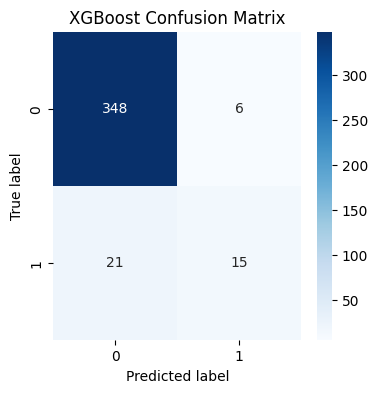

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

y_pred = best_xgb_model.predict(X_test_sc)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print("\nMetric Scores on Hold-out Test Set with Best XGB Model")
print(f"Accuracy            : {accuracy*100:.2f}%")
print(f"Macro Precision     : {precision*100:.2f}%")
print(f"Macro Recall        : {recall*100:.2f}%")
print(f"F1-Score            : {f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plot_confusion_matrix(cm, "XGBoost Confusion Matrix")